# Dead Reckoning from Phone & Watch IMU Data

## Indoor Localization from Sensor Logger Recordings

This notebook builds a **pedestrian dead reckoning (PDR)** trajectory from Sensor Logger recordings and compares phone vs. watch vs. fused estimates. It uses the `pdr/` package alongside this notebook — keep them in the same folder.

### What is dead reckoning?

Given a starting position and heading, dead reckoning incrementally estimates where you are by combining motion measurements over time. For pedestrians, the standard pipeline is:

1. **Detect steps** from accelerometer peaks (foot strikes show up as ~2 Hz spikes).
2. **Estimate step length** per step (Weinberg's heuristic from peak amplitude).
3. **Get heading** at each step from the IMU — gyro alone drifts, magnetometer alone is noisy, so we fuse them with a **1-D Kalman filter (EKF)**.
4. **Walk forward** step by step in 2D using `(Δx, Δy) = L · (cos ψ, sin ψ)`.

We do *not* double-integrate acceleration to get position — that drifts catastrophically (meters per second within a few seconds) because of gravity-removal errors and IMU bias.

### Notebook structure

1. Setup & paths
2. Walking recording — load, preprocess, detect steps
3. Heading: gyro vs. compass vs. EKF
4. Trajectories: phone, watch, fused
5. Map overlay using the GPS fix
6. Stairs recording — add Z dimension via barometer
7. Discussion & next steps

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

from pdr import (
    load_recording,
    align_phone_watch, resample_to,
    detect_steps,
    HeadingEKF, integrate_gyro_heading, magnetometer_heading,
    compute_trajectory, PDRConfig,
    pressure_to_altitude,
    viz,
)
from pdr.pdr import fuse_trajectories

print('PDR module loaded.')

PDR module loaded.


In [4]:
WALKING_DIR = Path('../data/walking-sitting/default')
STAIRS_DIR  = Path('../data/upstairs-downstairs/default')

# Common processing parameters
FS = 60.0                  # target sampling rate (Hz). Phone IMU caps near 54 Hz, so 60 Hz is a slight up-sample.
WEINBERG_K = 0.41          # step-length scaling. Calibrate per user against a measured walk.
MIN_PEAK_HEIGHT = 1.2      # m/s², threshold on filtered |a| for a foot strike.
MIN_PEAK_DISTANCE = 0.30   # seconds, caps cadence at ~3.3 Hz.

## 2. Walking Recording: load + preprocess

We load the Sensor Logger CSVs and resample phone + watch onto a single 60 Hz time grid. The `align_phone_watch` helper picks the time window where both devices have data and resamples each sensor with linear interpolation (quaternions are renormalised after interpolation).

In [5]:
rec_walk = load_recording(WALKING_DIR)
print(f'Annotations: {rec_walk.annotation_dict()}')
phone_walk, watch_walk = align_phone_watch(rec_walk.phone, rec_walk.watch, fs=FS)
print(f'Resampled to {FS} Hz; phone accel rows = {len(phone_walk.accel_total)} '
      f'(≈ {len(phone_walk.accel_total)/FS:.1f} s)')

Loaded default: phone=10 sensors, watch=8 sensors, annotations=2, duration=42.0s
Annotations: {'Walking': 4.397, 'Sitting': 27.103}
Resampled to 60.0 Hz; phone accel rows = 2324 (≈ 38.7 s)


## 3. Step detection

Step detection runs on **total acceleration** (magnitude of `accel_total`, which includes gravity). The function low-pass filters at 3 Hz, finds peaks above threshold with a minimum spacing of 0.3 s, and computes a Weinberg step length per step.

If the recording was annotated with walking/sitting transitions, you'll see them as shaded background bands.

In [6]:
# Phone steps
p_accel = phone_walk.accel_total[['x','y','z']].to_numpy()
p_t = phone_walk.accel_total['seconds_elapsed'].to_numpy()
phone_steps = detect_steps(p_accel, fs=FS, seconds_elapsed=p_t,
                            min_peak_height=MIN_PEAK_HEIGHT,
                            min_peak_distance_s=MIN_PEAK_DISTANCE,
                            weinberg_k=WEINBERG_K,
                            use_total_accel=True)
print(f'Phone: {len(phone_steps)} steps detected, mean length '
      f'{np.mean([s.length for s in phone_steps]):.3f} m')

# Watch steps (if available)
if watch_walk.accel_total is not None:
    w_accel = watch_walk.accel_total[['x','y','z']].to_numpy()
    w_t = watch_walk.accel_total['seconds_elapsed'].to_numpy()
    watch_steps = detect_steps(w_accel, fs=FS, seconds_elapsed=w_t,
                                min_peak_height=MIN_PEAK_HEIGHT,
                                min_peak_distance_s=MIN_PEAK_DISTANCE,
                                weinberg_k=WEINBERG_K,
                                use_total_accel=True)
    print(f'Watch: {len(watch_steps)} steps detected, mean length '
          f'{np.mean([s.length for s in watch_steps]):.3f} m')
else:
    watch_steps = None
    print('No watch acceleration available.')

Phone: 34 steps detected, mean length 0.695 m
Watch: 33 steps detected, mean length 0.644 m


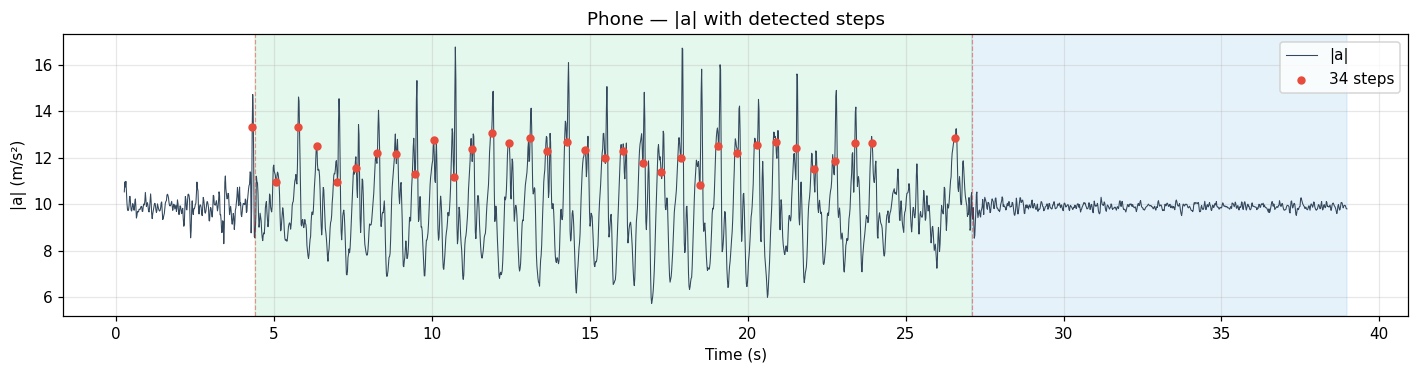

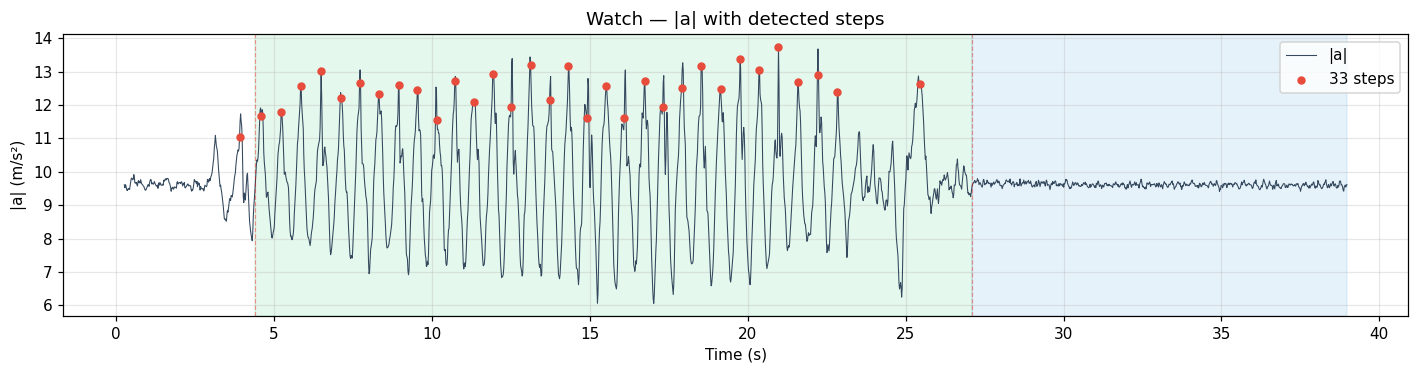

In [7]:
# Visualize step detection for both devices
ann = rec_walk.annotation_dict()
viz.plot_step_detection(p_t, p_accel, phone_steps,
                        title='Phone — |a| with detected steps', annotations=ann)
if watch_steps is not None:
    viz.plot_step_detection(w_t, w_accel, watch_steps,
                            title='Watch — |a| with detected steps', annotations=ann)
plt.show()

**What to check here:**
- Steps should cluster in the *walking* shaded region and disappear in *sitting*.
- If you see steps in the sitting region, raise `MIN_PEAK_HEIGHT`.
- If you see two markers per real step (heel + toe), raise `MIN_PEAK_DISTANCE`.
- The watch usually shows fewer steps because arm swing is less symmetric than torso bounce; this is normal.

## 4. Heading: gyro vs. compass vs. EKF

Three candidate heading sources:
1. **Gyro integrated** — smooth, drifts due to bias.
2. **Compass** — magnetometer atan2; absolute but noisy and disturbed by indoor metal/magnets.
3. **EKF fused** — 1-D Kalman filter that predicts with gyro and corrects with compass.
4. **OS / Madgwick yaw** — the yaw component of `Orientation.csv`. Often the best free lunch on Android.

We compute all four for the phone (and gyro+compass+EKF for the watch) and overlay them. A good EKF should track the OS-fused yaw closely.

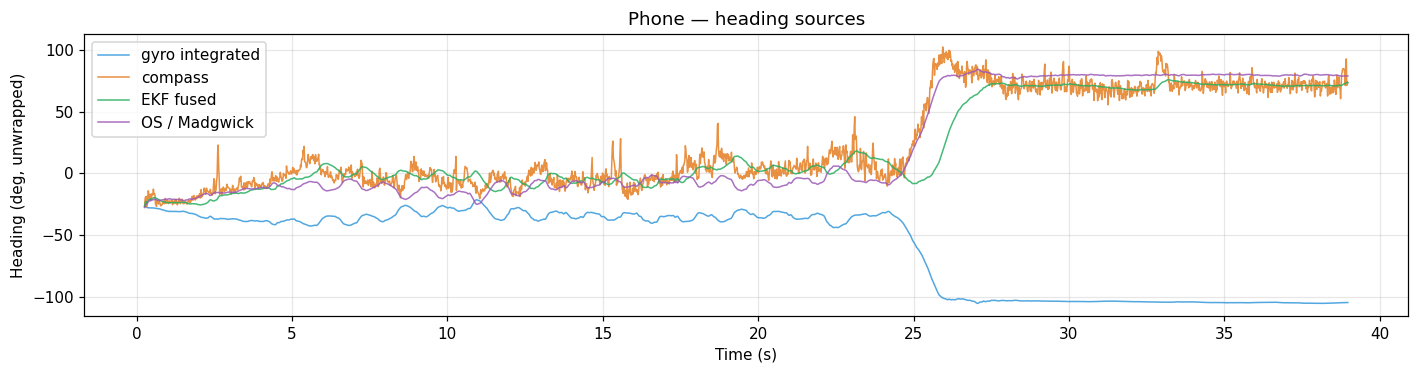

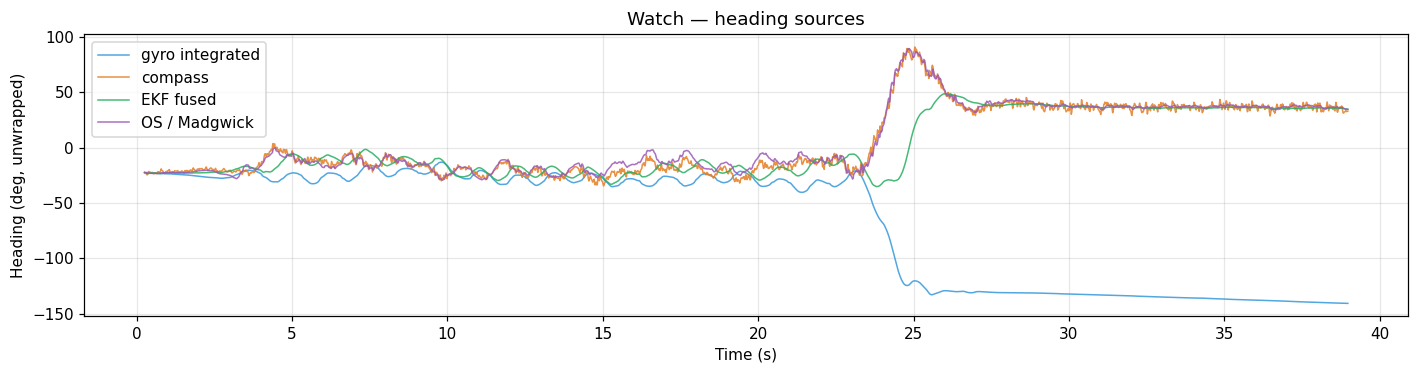

In [8]:
def compute_headings(device, fs):
    """Return (t, gyro_int, compass, ekf, os_yaw) for a single device."""
    if device.gyro is None:
        return None
    gz = device.gyro['z'].to_numpy()
    t  = device.gyro['seconds_elapsed'].to_numpy()

    # Compass from magnetometer with optional tilt compensation via gravity.
    if device.magnet is not None:
        m = device.magnet[['x','y','z']].to_numpy()
        if device.gravity is not None and len(device.gravity) == len(m):
            g = device.gravity[['x','y','z']].to_numpy()
            comp = magnetometer_heading(m, gravity_xyz=g)
        else:
            comp = magnetometer_heading(m)
    else:
        comp = None

    # Gyro-only integrated heading
    init = float(comp[0]) if comp is not None else 0.0
    psi_gyro = integrate_gyro_heading(gz, fs=fs, initial_heading=init)

    # EKF (only if we have a compass to update with)
    if comp is not None:
        ekf = HeadingEKF(Q=1e-4, R=0.25)
        psi_ekf = ekf.run(gz, comp, fs=fs)
    else:
        psi_ekf = psi_gyro

    # OS / Madgwick yaw if available (Sensor Logger Orientation.csv has it)
    if device.orientation is not None and 'yaw' in device.orientation.columns:
        os_yaw = device.orientation['yaw'].to_numpy()
    else:
        os_yaw = None

    return t, psi_gyro, comp, psi_ekf, os_yaw

phone_h = compute_headings(phone_walk, FS)
watch_h = compute_headings(watch_walk, FS) if watch_walk.gyro is not None else None

if phone_h is not None:
    t, gyro_int, comp, ekf_h, os_yaw = phone_h
    viz.plot_heading_sources(t, gyro_only=gyro_int, compass=comp, fused=ekf_h,
                              sensor_fusion=os_yaw, title='Phone — heading sources')
if watch_h is not None:
    t2, gyro2, comp2, ekf2, os2 = watch_h
    viz.plot_heading_sources(t2, gyro_only=gyro2, compass=comp2, fused=ekf2,
                              sensor_fusion=os2, title='Watch — heading sources')
plt.show()

**What to look for:**
- The **gyro-only** line should drift away from the others over the recording — that's the bias.
- The **compass** is the noisiest; large jumps usually mean magnetic disturbance.
- The **EKF** sits between them, tracking the OS-fused yaw fairly closely.
- If the EKF is too jumpy, increase `R` (compass less trusted). If it drifts with the gyro, decrease `R`.

## 5. Trajectories: phone, watch, fused

We use the EKF heading from each device. Comparing phone vs. watch trajectories is itself diagnostic — if they disagree wildly, one of them is mounted somewhere weird (pocket vs. hand changes the heading frame).

The naive fused trajectory is a step-by-step average; it's most useful as a sanity check, not a real fused estimator.

phone (EKF)          34 steps   23.63 m  end (E,N) = (+23.21, +0.31) m
watch (EKF)          33 steps   21.25 m  end (E,N) = (+20.01, -5.99) m
phone (OS yaw)       34 steps   23.63 m  end (E,N) = (+22.74, -3.00) m
fused (50/50)        34 steps   23.63 m  end (E,N) = (+23.21, +0.31) m


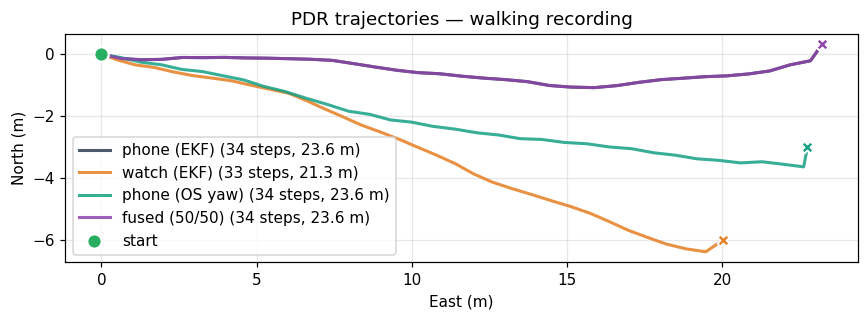

In [9]:
trajectories = {}

# Phone trajectory using EKF heading
if phone_h is not None and len(phone_steps):
    t_p, _, _, ekf_p, _ = phone_h
    res_phone = compute_trajectory(phone_steps, ekf_p, t_p)
    trajectories['phone (EKF)'] = res_phone

# Watch trajectory using EKF heading
if watch_h is not None and watch_steps and len(watch_steps):
    t_w, _, _, ekf_w, _ = watch_h
    res_watch = compute_trajectory(watch_steps, ekf_w, t_w)
    trajectories['watch (EKF)'] = res_watch

# Phone with OS yaw (when available) — often the cleanest reference
if phone_h is not None and phone_h[4] is not None and len(phone_steps):
    t_p, _, _, _, os_p = phone_h
    res_phone_os = compute_trajectory(phone_steps, os_p, t_p)
    trajectories['phone (OS yaw)'] = res_phone_os

# Naive fused (phone + watch step-aligned average)
if 'phone (EKF)' in trajectories and 'watch (EKF)' in trajectories:
    fused = fuse_trajectories(trajectories['phone (EKF)'],
                              trajectories['watch (EKF)'], weight_a=0.5)
    if fused.n_steps == trajectories['phone (EKF)'].n_steps:
        trajectories['fused (50/50)'] = fused
    else:
        print(f"Skipping fused: phone {trajectories['phone (EKF)'].n_steps} steps "
              f"vs watch {trajectories['watch (EKF)'].n_steps} steps.")

for label, res in trajectories.items():
    end = res.xy[-1]
    print(f"{label:18s}  {res.n_steps:3d} steps  {res.total_distance:6.2f} m  "
          f"end (E,N) = ({end[0]:+.2f}, {end[1]:+.2f}) m")

viz.plot_trajectories(trajectories, title='PDR trajectories — walking recording')
plt.show()

**Reading the trajectory plot:**
- Axes are East-North in metres, with the origin at the start.
- A trajectory that doubles back, loops, or takes a sharp 180° turn usually means the heading source jumped (compass spike) or the user actually turned around.
- If phone and watch trajectories diverge by more than ~10 m on a short recording, suspect heading-frame alignment between devices.

## 6. Map overlay using GPS

We anchor the PDR trajectory at the first GPS fix and overlay it on an OpenStreetMap basemap (via `contextily`). The first time this runs it fetches tiles from OSM — needs network access. After that, tiles are cached locally.

**Caveat:** Indoor GPS fixes can be off by tens of metres. The trajectory shape is what matters; the absolute placement on the map is approximate.

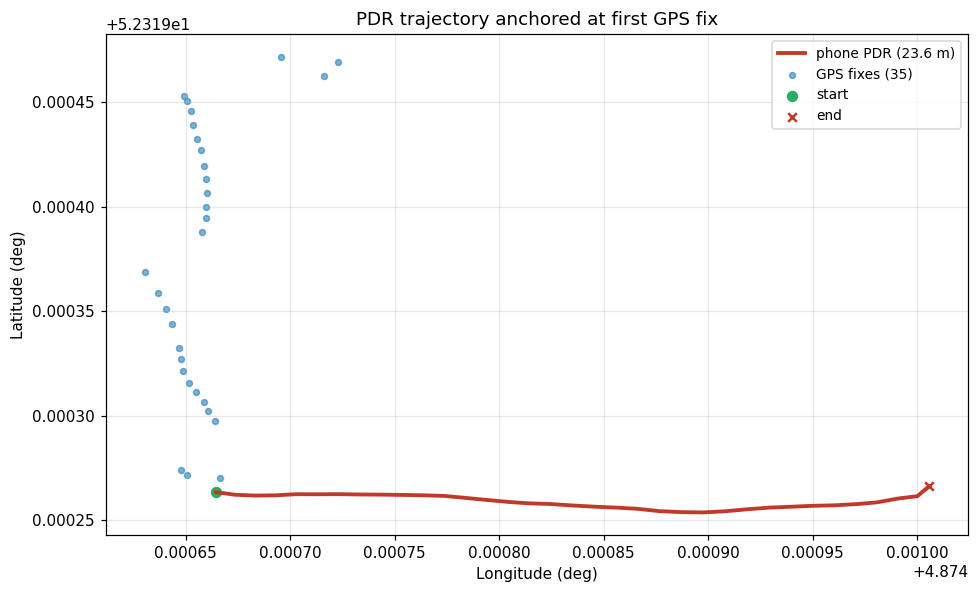

In [10]:
if rec_walk.phone.location is not None and not rec_walk.phone.location.empty \
        and 'phone (EKF)' in trajectories:
    fig = viz.plot_trajectory_on_map(
        trajectories['phone (EKF)'],
        rec_walk.phone.location,
        label='phone PDR',
        title='PDR trajectory anchored at first GPS fix',
        with_basemap=True,   # set False to skip the tile fetch
    )
    plt.show()
else:
    print('No GPS data in this recording — skipping map overlay.')

## 7. Stairs Recording: add Z dimension via barometer

Stairs introduce a vertical component PDR ignores by default. The barometer is the right tool for this — a 3 m floor change (~one storey) shows up as ~0.36 hPa, well above the noise floor of even a phone-grade barometer.

We compute relative altitude and overlay it with the activity annotations. Walking *upstairs* should show a clean ramp upward; walking *downstairs* the reverse. Sitting/standing landings appear flat.

Loaded default: phone=10 sensors, watch=7 sensors, annotations=2, duration=28.6s
Stairs annotations: {'Upstairs': 3.429, 'Downstairs': 16.646}
Total altitude span: 12.76 m


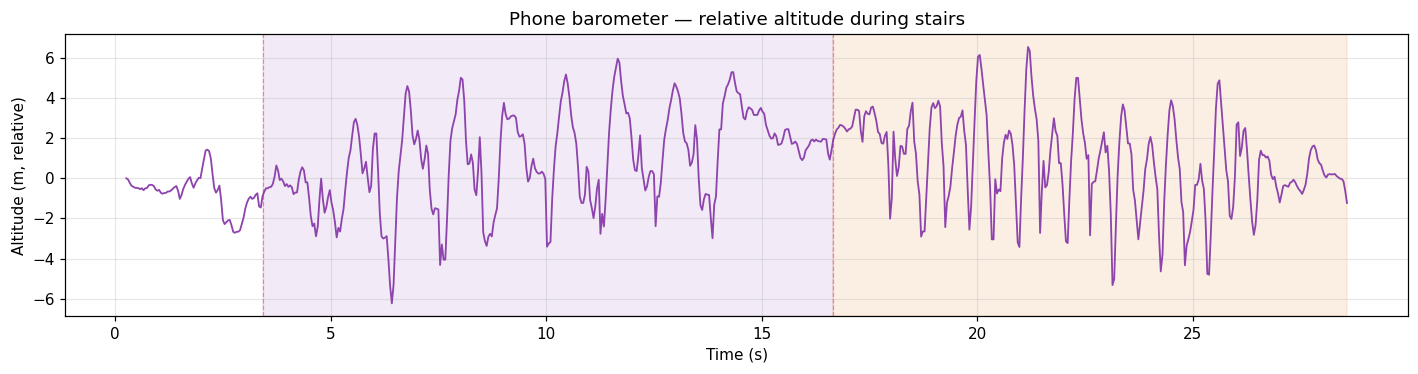

In [11]:
rec_stairs = load_recording(STAIRS_DIR)
print(f'Stairs annotations: {rec_stairs.annotation_dict()}')

# Barometer: prefer relativeAltitude if present, else compute from pressure.
baro = rec_stairs.phone.barometer
if baro is None:
    print('No phone barometer in this recording.')
else:
    if 'relativeAltitude' in baro.columns:
        alt = baro['relativeAltitude'].to_numpy() - baro['relativeAltitude'].iloc[0]
    else:
        alt = pressure_to_altitude(baro['pressure'].to_numpy())
    t_baro = baro['seconds_elapsed'].to_numpy()
    viz.plot_altitude(t_baro, alt, annotations=rec_stairs.annotation_dict(),
                      title='Phone barometer — relative altitude during stairs')
    print(f'Total altitude span: {alt.max() - alt.min():.2f} m')
    plt.show()

Stairs: 16 steps detected.


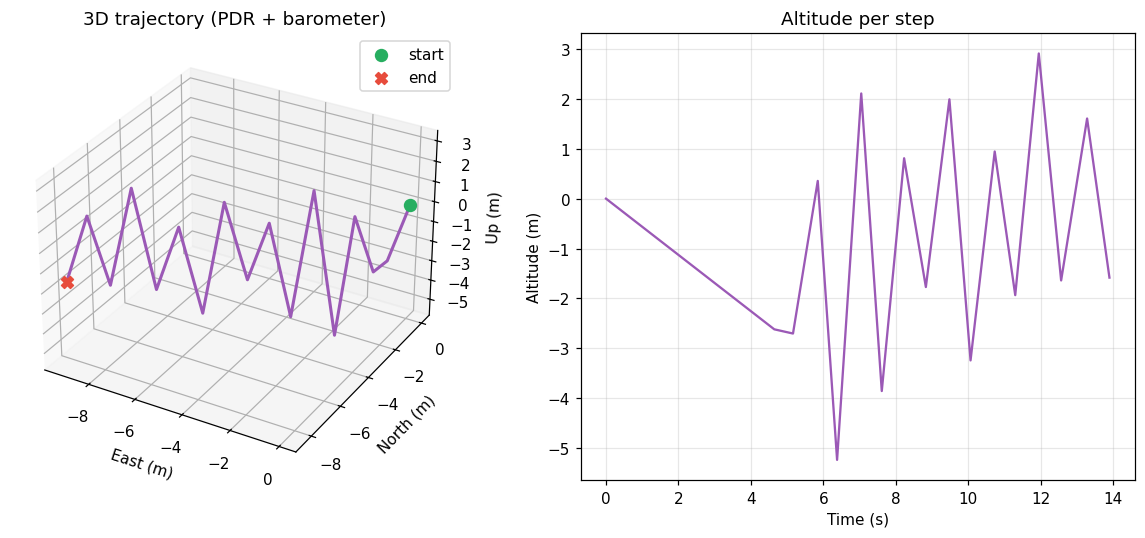

In [12]:
# Now build the 2D trajectory for the stairs recording too, so we can plot a
# pseudo-3D path: (E, N) from PDR, Z from barometer.
phone_st, watch_st = align_phone_watch(rec_stairs.phone, rec_stairs.watch, fs=FS)

p_acc_st = phone_st.accel_total[['x','y','z']].to_numpy()
p_t_st = phone_st.accel_total['seconds_elapsed'].to_numpy()
stair_steps = detect_steps(p_acc_st, fs=FS, seconds_elapsed=p_t_st,
                            min_peak_height=MIN_PEAK_HEIGHT,
                            min_peak_distance_s=MIN_PEAK_DISTANCE,
                            weinberg_k=WEINBERG_K, use_total_accel=True)
print(f'Stairs: {len(stair_steps)} steps detected.')

# Heading
stair_h = compute_headings(phone_st, FS)
if stair_h is not None and stair_steps:
    _, _, _, ekf_st, _ = stair_h
    res_stairs = compute_trajectory(stair_steps, ekf_st, p_t_st)

    fig = plt.figure(figsize=(11, 5))
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    # Z per step: interpolate barometer onto step times.
    if rec_stairs.phone.barometer is not None:
        baro = rec_stairs.phone.barometer
        t_b = baro['seconds_elapsed'].to_numpy()
        if 'relativeAltitude' in baro.columns:
            z_b = baro['relativeAltitude'].to_numpy() - baro['relativeAltitude'].iloc[0]
        else:
            z_b = pressure_to_altitude(baro['pressure'].to_numpy())
        z_at_steps = np.interp([0.0] + [s.time for s in stair_steps], t_b, z_b)
    else:
        z_at_steps = np.zeros(res_stairs.n_steps + 1)
    ax3d.plot(res_stairs.xy[:,0], res_stairs.xy[:,1], z_at_steps,
              color='#9b59b6', linewidth=2)
    ax3d.scatter(res_stairs.xy[0,0], res_stairs.xy[0,1], z_at_steps[0],
                 color='#27ae60', s=60, label='start')
    ax3d.scatter(res_stairs.xy[-1,0], res_stairs.xy[-1,1], z_at_steps[-1],
                 color='#e74c3c', s=60, marker='X', label='end')
    ax3d.set_xlabel('East (m)'); ax3d.set_ylabel('North (m)'); ax3d.set_zlabel('Up (m)')
    ax3d.set_title('3D trajectory (PDR + barometer)')
    ax3d.legend()

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.plot([0.0] + [s.time for s in stair_steps], z_at_steps,
             color='#9b59b6', linewidth=1.5)
    ax2.set_xlabel('Time (s)'); ax2.set_ylabel('Altitude (m)')
    ax2.set_title('Altitude per step')
    ax2.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print('Stairs heading or step detection failed — inspect the data.')

## 8. Discussion & Next Steps

**What is done:**
- Reusable PDR pipeline in `pdr/` that handles step detection, heading EKF, and trajectory generation.
- A side-by-side phone vs. watch comparison — useful as a sanity check that both devices agree on the user's path.
- A barometer-based Z dimension that captures stair climbing without trying to integrate vertical acceleration.
- A map overlay anchored at the first GPS fix.

**Some Notes:**

1. **Step length is uncalibrated.** Weinberg's K=0.41 is generic. Walk a known distance (e.g. a 20 m corridor, count steps) and tune K so the trajectory length matches.

2. **Gyro bias is not estimated.** Right now the EKF compensates implicitly via the magnetometer update. A better implementation extends the state to `[ψ, b]` so the bias is estimated and the gyro contribution gets cleaner.

3. **Magnetic disturbance detection is missing.** Indoor steel/electronics make the compass jump. Detect this (e.g., flag samples where `|m|` is outside ~25–65 μT or where d|m|/dt is large) and pass `compass_mask` to `HeadingEKF.run()`.

4. **Phone vs. watch heading frame.** The two devices likely have different yaw conventions depending on how they're held. For a real fused estimator, align them at the start of the recording (e.g., known initial heading) before fusing.

5. **GPS isn't fed back into PDR.** When a clean GPS fix is available, it could be used as an absolute position update in a 2D EKF over `[x, y, ψ]`. Useful for outdoor segments of a mixed indoor-outdoor walk.

6. **Stairs detection is implicit.** The barometer trace shows the climb but we don't classify steps as "stair-step" vs "walking-step". Stair steps are typically shorter (~0.25 m horizontal) than walking steps; using stride length conditioned on |dz/dt| would improve trajectory accuracy on stairs.